<a href="https://colab.research.google.com/github/eshghinezhad/DeepLearning/blob/master/Weather%20Forecasting%20with%20Sequence%20Models/scenario2_rnn_weather.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Weather Forecasting with Sequence Models — Scenario 2

**Scenario 2: Multi-step (14 → 3)**
Feature: `BASEL_temp_mean` · Slide a 14-day window, predict the next **3 days at once**.

Same as Scenario 1, except `HORIZON = 3` instead of `1`, so every model's `output_size` becomes 3.
Still a **many-to-one** framing: the whole 14-day window is consumed, and only the final hidden
state is used to produce all 3 forecasted days at once (not a step-by-step / seq2seq prediction).

- **S2-a** Simple RNN
- **S2-b** Deeper RNN
- **S2-c** LSTM
- **S2-d** GRU

> **Colab note:** upload `weather_prediction_dataset.csv` to the session directory before running.


## 0. Setup

In [1]:
import sys, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Using device: {device}")


Using device: cuda


## 1. Load the Dataset

In [3]:
DATA_PATH = "weather_prediction_dataset.csv"  # <-- adjust if needed

df = pd.read_csv(DATA_PATH)
df["DATE"] = pd.to_datetime(df["DATE"], format="%Y%m%d")
df = df.sort_values("DATE").set_index("DATE")

print(f"Dataset shape: {df.shape}")
print(f"{len(df)} daily records from {df.index.min().date()} to {df.index.max().date()}")
print(f"Missing values: {df.isna().sum().sum()}")


Dataset shape: (3654, 164)
3654 daily records from 2000-01-01 to 2010-01-01
Missing values: 0


## 2. Prepare the Dataset for Scenario 2

Same split / standardization approach as Scenario 1 — only `HORIZON` changes.

In [4]:
# --- 2.1 Chronological 70/30 split, with a validation holdout carved from the 70% ---
n = len(df)
test_start = int(n * 0.70)
train_val_df = df.iloc[:test_start]
test_df = df.iloc[test_start:]

val_start = int(len(train_val_df) * 0.85)
train_df = train_val_df.iloc[:val_start]
val_df = train_val_df.iloc[val_start:]

print(f"train: {train_df.index.min().date()} -> {train_df.index.max().date()}  ({len(train_df)} rows)")
print(f"val:   {val_df.index.min().date()} -> {val_df.index.max().date()}  ({len(val_df)} rows)")
print(f"test:  {test_df.index.min().date()} -> {test_df.index.max().date()}  ({len(test_df)} rows)")


train: 2000-01-01 -> 2005-12-12  (2173 rows)
val:   2005-12-13 -> 2006-12-31  (384 rows)
test:  2007-01-01 -> 2010-01-01  (1097 rows)


In [5]:
# --- 2.2 Standardize using TRAIN statistics only ---
feature_cols_s2 = ["BASEL_temp_mean"]

train_mean = train_df[feature_cols_s2].mean()
train_std = train_df[feature_cols_s2].std()

def standardize(frame):
    return (frame[feature_cols_s2] - train_mean) / train_std

train_s2 = torch.FloatTensor(standardize(train_df).values)
val_s2   = torch.FloatTensor(standardize(val_df).values)
test_s2  = torch.FloatTensor(standardize(test_df).values)

train_s2.shape, val_s2.shape, test_s2.shape


(torch.Size([2173, 1]), torch.Size([384, 1]), torch.Size([1097, 1]))

In [6]:
# --- 2.3 Base sliding-window Dataset (same as Scenario 1) ---
class TimeSeriesDataset(Dataset):
    '''
    series: FloatTensor of shape (T, num_columns), already standardized
    window_length: number of past steps the model sees
    horizon: number of future steps to predict (>=1)
    '''
    def __init__(self, series, window_length, horizon):
        self.series = series
        self.window_length = window_length
        self.horizon = horizon

    def __len__(self):
        return len(self.series) - self.window_length - self.horizon + 1

    def __getitem__(self, idx):
        if idx >= len(self):
            raise IndexError("dataset index out of range")
        end = idx + self.window_length
        window = self.series[idx: end]
        target = self.series[end: end + self.horizon]
        return window, target


In [7]:
# --- 2.4 Scenario-2-specific subclass ---
# Same univariate input as Scenario 1, but horizon=3 now -> target flattens to shape (3,)
class Scenario2Dataset(TimeSeriesDataset):
    def __getitem__(self, idx):
        window, target = super().__getitem__(idx)
        target = target.reshape(-1)   # (horizon=3, 1 col) -> flat vector shape (3,)
        return window, target


In [8]:
WINDOW_LENGTH = 14
HORIZON = 3   # <-- the only real change from Scenario 1

s2_train_set = Scenario2Dataset(train_s2, WINDOW_LENGTH, HORIZON)
s2_val_set   = Scenario2Dataset(val_s2,   WINDOW_LENGTH, HORIZON)
s2_test_set  = Scenario2Dataset(test_s2,  WINDOW_LENGTH, HORIZON)

BATCH_SIZE = 32
s2_train_loader = DataLoader(s2_train_set, batch_size=BATCH_SIZE, shuffle=True)
s2_val_loader   = DataLoader(s2_val_set,   batch_size=BATCH_SIZE)
s2_test_loader  = DataLoader(s2_test_set,  batch_size=BATCH_SIZE)

xb, yb = next(iter(s2_train_loader))
print("window batch shape:", xb.shape)   # expect (batch, 14, 1)
print("target batch shape:", yb.shape)   # expect (batch, 3)


window batch shape: torch.Size([32, 14, 1])
target batch shape: torch.Size([32, 3])


## 3. Build & Train the Models (S2-a to S2-d)

Identical architectures to Scenario 1, just `output_size=3` now. The evaluation function also
reports **per-day MAE** (day+1, day+2, day+3) alongside the overall MAE, so you can see whether
accuracy degrades further into the horizon.

In [9]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


@torch.no_grad()
def evaluate_mae(model, loader, horizon):
    model.eval()
    total_abs_err, n = 0.0, 0
    per_day_abs_err = torch.zeros(horizon)
    per_day_n = 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        err = (y_pred - y).abs()
        total_abs_err += err.sum().item()
        n += y.numel()
        per_day_abs_err += err.sum(dim=0).cpu()
        per_day_n += y.shape[0]
    overall_mae = total_abs_err / n
    per_day_mae = (per_day_abs_err / per_day_n).tolist()
    return overall_mae, per_day_mae


def train_and_evaluate(model, train_loader, val_loader, test_loader,
                        lr=1e-3, n_epochs=20, model_name="model", horizon=3):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    start = time.time()
    for epoch in range(n_epochs):
        model.train()
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_pred = model(X)
            loss = loss_fn(y_pred, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        val_mae, _ = evaluate_mae(model, val_loader, horizon)
        print(f"[{model_name}] epoch {epoch+1:>2}/{n_epochs} — val MAE (standardized units): {val_mae:.4f}")

    training_time = time.time() - start
    test_mae, test_per_day_mae = evaluate_mae(model, test_loader, horizon)

    return {
        "model": model_name,
        "params": count_params(model),
        "training_time_sec": round(training_time, 2),
        "val_mae": round(val_mae, 4),
        "test_mae": round(test_mae, 4),
        "test_mae_day1": round(test_per_day_mae[0], 4),
        "test_mae_day2": round(test_per_day_mae[1], 4),
        "test_mae_day3": round(test_per_day_mae[2], 4),
    }


results_s2 = []


### S2-a — Simple RNN

In [10]:
class SimpleRnnModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        outputs, _ = self.rnn(X)
        return self.output(outputs[:, -1])


torch.manual_seed(SEED)
s2a_model = SimpleRnnModel(input_size=1, hidden_size=32, output_size=3)
res = train_and_evaluate(s2a_model, s2_train_loader, s2_val_loader, s2_test_loader,
                          lr=0.01, n_epochs=20, model_name="S2-a SimpleRNN", horizon=HORIZON)
results_s2.append(res)
res


[S2-a SimpleRNN] epoch  1/20 — val MAE (standardized units): 0.3436
[S2-a SimpleRNN] epoch  2/20 — val MAE (standardized units): 0.3189
[S2-a SimpleRNN] epoch  3/20 — val MAE (standardized units): 0.3457
[S2-a SimpleRNN] epoch  4/20 — val MAE (standardized units): 0.3233
[S2-a SimpleRNN] epoch  5/20 — val MAE (standardized units): 0.3319
[S2-a SimpleRNN] epoch  6/20 — val MAE (standardized units): 0.3229
[S2-a SimpleRNN] epoch  7/20 — val MAE (standardized units): 0.3422
[S2-a SimpleRNN] epoch  8/20 — val MAE (standardized units): 0.3346
[S2-a SimpleRNN] epoch  9/20 — val MAE (standardized units): 0.3196
[S2-a SimpleRNN] epoch 10/20 — val MAE (standardized units): 0.3204
[S2-a SimpleRNN] epoch 11/20 — val MAE (standardized units): 0.3243
[S2-a SimpleRNN] epoch 12/20 — val MAE (standardized units): 0.3178
[S2-a SimpleRNN] epoch 13/20 — val MAE (standardized units): 0.3561
[S2-a SimpleRNN] epoch 14/20 — val MAE (standardized units): 0.3373
[S2-a SimpleRNN] epoch 15/20 — val MAE (standard

{'model': 'S2-a SimpleRNN',
 'params': 1219,
 'training_time_sec': 4.64,
 'val_mae': 0.322,
 'test_mae': 0.3057,
 'test_mae_day1': 0.2168,
 'test_mae_day2': 0.3242,
 'test_mae_day3': 0.3761}

### S2-b — Deeper RNN

In [11]:
class DeepRnnModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=3, dropout=0.0):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers=num_layers,
                          batch_first=True, dropout=dropout)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        outputs, _ = self.rnn(X)
        return self.output(outputs[:, -1])


torch.manual_seed(SEED)
s2b_model = DeepRnnModel(input_size=1, hidden_size=32, output_size=3, num_layers=3, dropout=0.1)
res = train_and_evaluate(s2b_model, s2_train_loader, s2_val_loader, s2_test_loader,
                          lr=0.01, n_epochs=20, model_name="S2-b DeepRNN", horizon=HORIZON)
results_s2.append(res)
res


[S2-b DeepRNN] epoch  1/20 — val MAE (standardized units): 0.3821
[S2-b DeepRNN] epoch  2/20 — val MAE (standardized units): 0.3334
[S2-b DeepRNN] epoch  3/20 — val MAE (standardized units): 0.3655
[S2-b DeepRNN] epoch  4/20 — val MAE (standardized units): 0.3328
[S2-b DeepRNN] epoch  5/20 — val MAE (standardized units): 0.3465
[S2-b DeepRNN] epoch  6/20 — val MAE (standardized units): 0.4044
[S2-b DeepRNN] epoch  7/20 — val MAE (standardized units): 0.3364
[S2-b DeepRNN] epoch  8/20 — val MAE (standardized units): 0.3366
[S2-b DeepRNN] epoch  9/20 — val MAE (standardized units): 0.3424
[S2-b DeepRNN] epoch 10/20 — val MAE (standardized units): 0.3446
[S2-b DeepRNN] epoch 11/20 — val MAE (standardized units): 0.3602
[S2-b DeepRNN] epoch 12/20 — val MAE (standardized units): 0.3501
[S2-b DeepRNN] epoch 13/20 — val MAE (standardized units): 0.3841
[S2-b DeepRNN] epoch 14/20 — val MAE (standardized units): 0.3432
[S2-b DeepRNN] epoch 15/20 — val MAE (standardized units): 0.3528
[S2-b Deep

{'model': 'S2-b DeepRNN',
 'params': 5443,
 'training_time_sec': 4.82,
 'val_mae': 0.3947,
 'test_mae': 0.344,
 'test_mae_day1': 0.2748,
 'test_mae_day2': 0.3606,
 'test_mae_day3': 0.3967}

### S2-c — LSTM

In [12]:
class LstmModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.rnn = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        outputs, _ = self.rnn(X)
        return self.output(outputs[:, -1])


torch.manual_seed(SEED)
s2c_model = LstmModel(input_size=1, hidden_size=32, output_size=3)
res = train_and_evaluate(s2c_model, s2_train_loader, s2_val_loader, s2_test_loader,
                          lr=0.01, n_epochs=20, model_name="S2-c LSTM", horizon=HORIZON)
results_s2.append(res)
res


[S2-c LSTM] epoch  1/20 — val MAE (standardized units): 0.3611
[S2-c LSTM] epoch  2/20 — val MAE (standardized units): 0.3437
[S2-c LSTM] epoch  3/20 — val MAE (standardized units): 0.3314
[S2-c LSTM] epoch  4/20 — val MAE (standardized units): 0.3128
[S2-c LSTM] epoch  5/20 — val MAE (standardized units): 0.3133
[S2-c LSTM] epoch  6/20 — val MAE (standardized units): 0.3143
[S2-c LSTM] epoch  7/20 — val MAE (standardized units): 0.3215
[S2-c LSTM] epoch  8/20 — val MAE (standardized units): 0.3287
[S2-c LSTM] epoch  9/20 — val MAE (standardized units): 0.3167
[S2-c LSTM] epoch 10/20 — val MAE (standardized units): 0.3087
[S2-c LSTM] epoch 11/20 — val MAE (standardized units): 0.3205
[S2-c LSTM] epoch 12/20 — val MAE (standardized units): 0.3141
[S2-c LSTM] epoch 13/20 — val MAE (standardized units): 0.3100
[S2-c LSTM] epoch 14/20 — val MAE (standardized units): 0.3195
[S2-c LSTM] epoch 15/20 — val MAE (standardized units): 0.3092
[S2-c LSTM] epoch 16/20 — val MAE (standardized units):

{'model': 'S2-c LSTM',
 'params': 4579,
 'training_time_sec': 4.15,
 'val_mae': 0.3168,
 'test_mae': 0.3026,
 'test_mae_day1': 0.214,
 'test_mae_day2': 0.3224,
 'test_mae_day3': 0.3715}

### S2-d — GRU

In [13]:
class GruModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.rnn = nn.GRU(input_size, hidden_size, batch_first=True)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        outputs, _ = self.rnn(X)
        return self.output(outputs[:, -1])


torch.manual_seed(SEED)
s2d_model = GruModel(input_size=1, hidden_size=32, output_size=3)
res = train_and_evaluate(s2d_model, s2_train_loader, s2_val_loader, s2_test_loader,
                          lr=0.01, n_epochs=20, model_name="S2-d GRU", horizon=HORIZON)
results_s2.append(res)
res


[S2-d GRU] epoch  1/20 — val MAE (standardized units): 0.3460
[S2-d GRU] epoch  2/20 — val MAE (standardized units): 0.3359
[S2-d GRU] epoch  3/20 — val MAE (standardized units): 0.3162
[S2-d GRU] epoch  4/20 — val MAE (standardized units): 0.3131
[S2-d GRU] epoch  5/20 — val MAE (standardized units): 0.3159
[S2-d GRU] epoch  6/20 — val MAE (standardized units): 0.3283
[S2-d GRU] epoch  7/20 — val MAE (standardized units): 0.3229
[S2-d GRU] epoch  8/20 — val MAE (standardized units): 0.3271
[S2-d GRU] epoch  9/20 — val MAE (standardized units): 0.3133
[S2-d GRU] epoch 10/20 — val MAE (standardized units): 0.3129
[S2-d GRU] epoch 11/20 — val MAE (standardized units): 0.3114
[S2-d GRU] epoch 12/20 — val MAE (standardized units): 0.3255
[S2-d GRU] epoch 13/20 — val MAE (standardized units): 0.3171
[S2-d GRU] epoch 14/20 — val MAE (standardized units): 0.3234
[S2-d GRU] epoch 15/20 — val MAE (standardized units): 0.3150
[S2-d GRU] epoch 16/20 — val MAE (standardized units): 0.3143
[S2-d GR

{'model': 'S2-d GRU',
 'params': 3459,
 'training_time_sec': 4.38,
 'val_mae': 0.3183,
 'test_mae': 0.2992,
 'test_mae_day1': 0.2137,
 'test_mae_day2': 0.3189,
 'test_mae_day3': 0.3649}

## 4. Compare Performance & Training Time

In [14]:
results_s2_df = pd.DataFrame(results_s2).set_index("model")
results_s2_df


,params,training_time_sec,val_mae,test_mae,test_mae_day1,test_mae_day2,test_mae_day3
model,,,,,,,
S2-a SimpleRNN,1219,4.64,0.3220,0.3057,0.2168,0.3242,0.3761
S2-b DeepRNN,5443,4.82,0.3947,0.3440,0.2748,0.3606,0.3967
S2-c LSTM,4579,4.15,0.3168,0.3026,0.2140,0.3224,0.3715
S2-d GRU,3459,4.38,0.3183,0.2992,0.2137,0.3189,0.3649


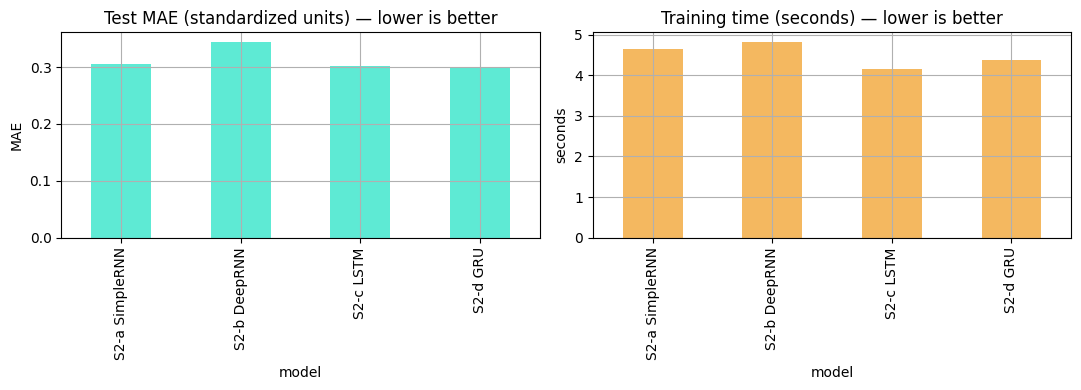

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

results_s2_df["test_mae"].plot(kind="bar", ax=axes[0], grid=True, color="#5eead4")
axes[0].set_title("Test MAE (standardized units) — lower is better")
axes[0].set_ylabel("MAE")

results_s2_df["training_time_sec"].plot(kind="bar", ax=axes[1], grid=True, color="#f4b860")
axes[1].set_title("Training time (seconds) — lower is better")
axes[1].set_ylabel("seconds")

plt.tight_layout()
plt.show()


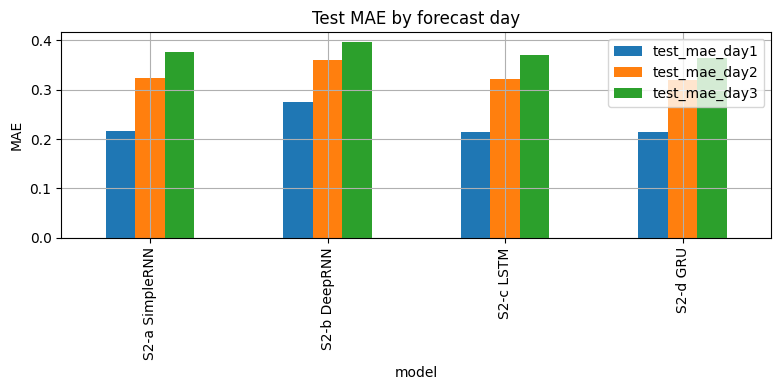

In [16]:
# Does accuracy degrade further into the 3-day horizon? Worth a look before writing the reflection.
results_s2_df[["test_mae_day1", "test_mae_day2", "test_mae_day3"]].plot(
    kind="bar", figsize=(8, 4), grid=True, title="Test MAE by forecast day"
)
plt.ylabel("MAE")
plt.tight_layout()
plt.show()


## 5. Reflection — Scenario 2

*Fill this in after running the cells and looking at your own numbers.*

**Accuracy — how does this compare to Scenario 1's results?**
- _e.g. did the model ranking (Simple RNN best, DeepRNN worst, etc.) stay the same as Scenario 1,
  or did predicting 3 days instead of 1 change which architecture wins?_

- _your observation here_

**Per-day breakdown — does accuracy get worse from day+1 to day+3?**
- _your observation here_

**Training time — how did it change compared to Scenario 1, given the only difference is `output_size`?**
- _your observation here_

**Overall takeaway for this scenario:**
- _your observation here_
